## This is a Heart Disease dataset. 

The goal is to predict if a patient has heart disease from clinical measurements taken during a routine visit or checkup — things like age, blood pressure, cholesterol, chest pain type, ECG results, and how the heart responds to exercise. It's a binary classification problem: given a new patient's data, predict Heart_Disease = 1 or 0.

In [280]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split


In [281]:
# import heart data
df = pd.read_csv("heart.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [282]:
# Check missing values
df.isnull().sum()


age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [283]:
# Fill if any missing
df["age"].fillna(df["age"].mean(), inplace=True)

C:\Users\shali\AppData\Local\Temp\ipykernel_4264\2469551126.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["age"].fillna(df["age"].mean(), inplace=True)


In [284]:
# Remove duplicates
df.drop_duplicates(inplace=True)

In [285]:
# Check data types
df.dtypes

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

In [286]:
# Rename columns to understandable names
df.rename(columns={
    "sex"      : "Gender",
    "cp"       : "Chest_Pain_Type",
    "trestbps" : "Resting_Blood_Pressure",
    "chol"     : "Cholesterol",
    "fbs"      : "Fasting_Blood_Sugar",
    "restecg"  : "Resting_ECG",
    "thalach"  : "Max_Heart_Rate",
    "exang"    : "Exercise_Induced_Angina",
    "oldpeak"  : "ST_Depression",
    "slope"    : "ST_Slope",
    "ca"       : "Blocked_Vessels",
    "thal"     : "Thalassemia",
    "target"   : "Heart_Disease"
}, inplace=True)

# Verify
print(df.columns)
print(df.head())

Index(['age', 'Gender', 'Chest_Pain_Type', 'Resting_Blood_Pressure',
       'Cholesterol', 'Fasting_Blood_Sugar', 'Resting_ECG', 'Max_Heart_Rate',
       'Exercise_Induced_Angina', 'ST_Depression', 'ST_Slope',
       'Blocked_Vessels', 'Thalassemia', 'Heart_Disease'],
      dtype='object')
   age  Gender  Chest_Pain_Type  Resting_Blood_Pressure  Cholesterol  \
0   52       1                0                     125          212   
1   53       1                0                     140          203   
2   70       1                0                     145          174   
3   61       1                0                     148          203   
4   62       0                0                     138          294   

   Fasting_Blood_Sugar  Resting_ECG  Max_Heart_Rate  Exercise_Induced_Angina  \
0                    0            1             168                        0   
1                    1            0             155                        1   
2                    0            1 

In [287]:
df.dtypes,df.shape,df.info(),df.columns

<class 'pandas.core.frame.DataFrame'>
Index: 302 entries, 0 to 878
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      302 non-null    int64  
 1   Gender                   302 non-null    int64  
 2   Chest_Pain_Type          302 non-null    int64  
 3   Resting_Blood_Pressure   302 non-null    int64  
 4   Cholesterol              302 non-null    int64  
 5   Fasting_Blood_Sugar      302 non-null    int64  
 6   Resting_ECG              302 non-null    int64  
 7   Max_Heart_Rate           302 non-null    int64  
 8   Exercise_Induced_Angina  302 non-null    int64  
 9   ST_Depression            302 non-null    float64
 10  ST_Slope                 302 non-null    int64  
 11  Blocked_Vessels          302 non-null    int64  
 12  Thalassemia              302 non-null    int64  
 13  Heart_Disease            302 non-null    int64  
dtypes: float64(1), int64(13)
memory

(age                          int64
 Gender                       int64
 Chest_Pain_Type              int64
 Resting_Blood_Pressure       int64
 Cholesterol                  int64
 Fasting_Blood_Sugar          int64
 Resting_ECG                  int64
 Max_Heart_Rate               int64
 Exercise_Induced_Angina      int64
 ST_Depression              float64
 ST_Slope                     int64
 Blocked_Vessels              int64
 Thalassemia                  int64
 Heart_Disease                int64
 dtype: object,
 (302, 14),
 None,
 Index(['age', 'Gender', 'Chest_Pain_Type', 'Resting_Blood_Pressure',
        'Cholesterol', 'Fasting_Blood_Sugar', 'Resting_ECG', 'Max_Heart_Rate',
        'Exercise_Induced_Angina', 'ST_Depression', 'ST_Slope',
        'Blocked_Vessels', 'Thalassemia', 'Heart_Disease'],
       dtype='object'))

In [288]:
df.describe()

,age,Gender,Chest_Pain_Type,Resting_Blood_Pressure,Cholesterol,Fasting_Blood_Sugar,Resting_ECG,Max_Heart_Rate,Exercise_Induced_Angina,ST_Depression,ST_Slope,Blocked_Vessels,Thalassemia,Heart_Disease
count,302.00000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000
mean,54.42053,0.682119,0.963576,131.602649,246.500000,0.149007,0.526490,149.569536,0.327815,1.043046,1.397351,0.718543,2.314570,0.543046
std,9.04797,0.466426,1.032044,17.563394,51.753489,0.356686,0.526027,22.903527,0.470196,1.161452,0.616274,1.006748,0.613026,0.498970
min,29.00000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.00000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.250000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.50000,1.000000,1.000000,130.000000,240.500000,0.000000,1.000000,152.500000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.00000,1.000000,2.000000,140.000000,274.750000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.00000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [289]:
# finding missing values 
df.isnull().sum()

age                        0
Gender                     0
Chest_Pain_Type            0
Resting_Blood_Pressure     0
Cholesterol                0
Fasting_Blood_Sugar        0
Resting_ECG                0
Max_Heart_Rate             0
Exercise_Induced_Angina    0
ST_Depression              0
ST_Slope                   0
Blocked_Vessels            0
Thalassemia                0
Heart_Disease              0
dtype: int64

In [290]:
df["Heart_Disease"].value_counts()

Heart_Disease
1    164
0    138
Name: count, dtype: int64

In [291]:
# this means that there are 164 people with diseases and 138 people with no diseases

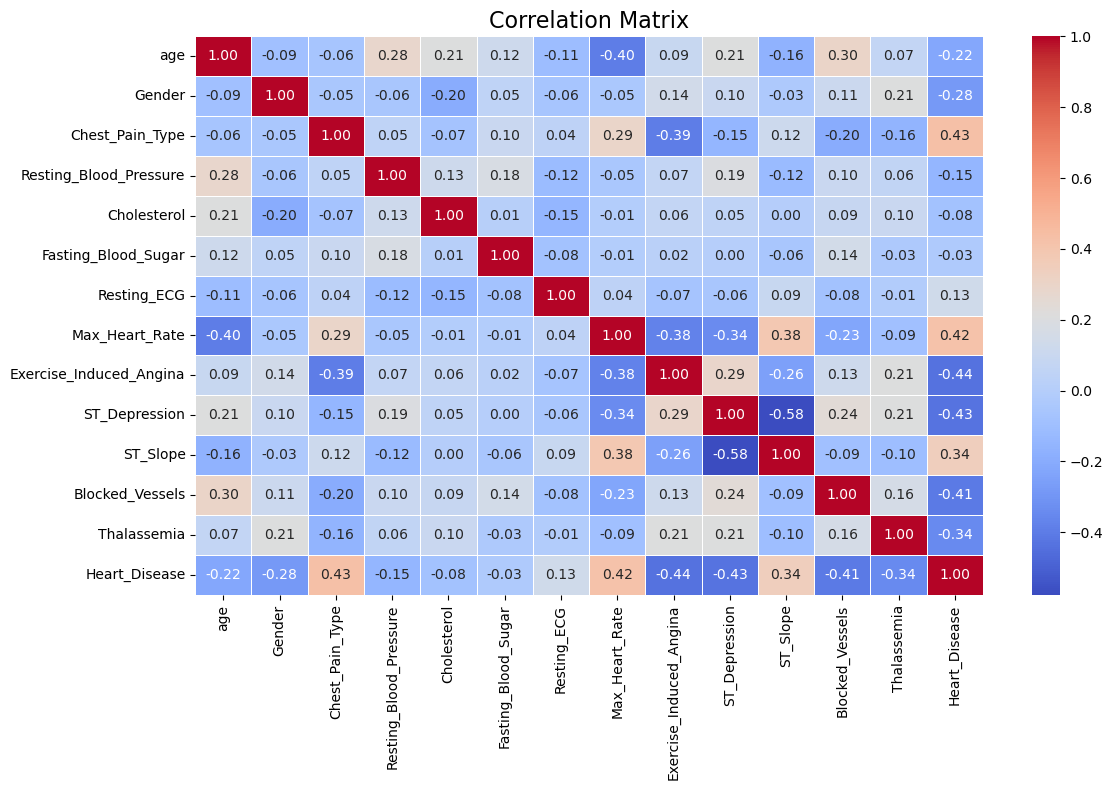

In [292]:
# correlation heatmap
plt.figure(figsize=(12, 8)) 

sns.heatmap(df.corr(),annot=True,cmap="coolwarm",fmt=".2f",linewidths=0.5)    

plt.title("Correlation Matrix", fontsize=16)
plt.tight_layout()  # prevents cutting off labels
plt.show()

In [293]:
df["Chest_Pain_Type"].value_counts()


Chest_Pain_Type
0    143
2     86
1     50
3     23
Name: count, dtype: int64

In [294]:
df["ST_Slope"].value_counts()


ST_Slope
2    141
1    140
0     21
Name: count, dtype: int64

In [295]:
df["Thalassemia"].value_counts()

Thalassemia
2    165
3    117
1     18
0      2
Name: count, dtype: int64

In [296]:
# See which features relate to Heart Disease 
df.corr()["Heart_Disease"].sort_values(ascending=False)

# Output example:
# Heart_Disease              1.00
# Chest_Pain_Type            0.43   strong
# Max_Heart_Rate             0.42   strong
# ST_Depression             -0.43   strong
# Exercise_Induced_Angina   -0.44   strong
# ST_Slope                   0.35   moderate
# Age                       -0.23   weak
# Cholesterol                0.08   very weak
# Fasting_Blood_Sugar        0.02   barely related

Heart_Disease              1.000000
Chest_Pain_Type            0.432080
Max_Heart_Rate             0.419955
ST_Slope                   0.343940
Resting_ECG                0.134874
Fasting_Blood_Sugar       -0.026826
Cholesterol               -0.081437
Resting_Blood_Pressure    -0.146269
age                       -0.221476
Gender                    -0.283609
Thalassemia               -0.343101
Blocked_Vessels           -0.408992
ST_Depression             -0.429146
Exercise_Induced_Angina   -0.435601
Name: Heart_Disease, dtype: float64

In [297]:
# Fasting_Blood_Sugar and Cholesterol barely relate to target
df.drop(columns=["Fasting_Blood_Sugar"], inplace=True)
#df.drop(columns=["Cholesterol"], inplace=True)

# not droping the Cholesterol imporved the accuracy

In [298]:
# Based on strong correlations

# 1. From Age (moderately related)
df["Senior"]= (df["age"] > 55).astype(int)
# old age causes higher risk

# 2. From Max_Heart_Rate (strongly related)
df["Low_Heart_Rate"]= (df["Max_Heart_Rate"] < 140).astype(int)
# low max heart rate cauese possible problem

# 3. Combine Age and Max_Heart_Rate (both related to target)
df["Heart_Rate_Age_Ratio"]= df["Max_Heart_Rate"] / df["age"]
# this combined feature might be more powerful

# 4. From ST_Depression (strongly related)
df["High_ST_Depression"]= (df["ST_Depression"] > 1.5).astype(int)
# high ST depression strong risk indicator

In [299]:
df[["Senior", "Low_Heart_Rate", "Heart_Rate_Age_Ratio", "High_ST_Depression", "Heart_Disease"]].corr()["Heart_Disease"].sort_values(ascending=False)

Heart_Disease           1.000000
Heart_Rate_Age_Ratio    0.379731
Senior                 -0.265888
Low_Heart_Rate         -0.327533
High_ST_Depression     -0.371876
Name: Heart_Disease, dtype: float64

In [300]:
df

,age,Gender,Chest_Pain_Type,Resting_Blood_Pressure,Cholesterol,Resting_ECG,Max_Heart_Rate,Exercise_Induced_Angina,ST_Depression,ST_Slope,Blocked_Vessels,Thalassemia,Heart_Disease,Senior,Low_Heart_Rate,Heart_Rate_Age_Ratio,High_ST_Depression
0,52,1,0,125,212,1,168,0,1.0,2,2,3,0,0,0,3.230769,0
1,53,1,0,140,203,0,155,1,3.1,0,0,3,0,0,0,2.924528,1
2,70,1,0,145,174,1,125,1,2.6,0,0,3,0,1,1,1.785714,1
3,61,1,0,148,203,1,161,0,0.0,2,1,3,0,1,0,2.639344,0
4,62,0,0,138,294,1,106,0,1.9,1,3,2,0,1,1,1.709677,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
723,68,0,2,120,211,0,115,0,1.5,1,0,2,1,1,1,1.691176,0
733,44,0,2,108,141,1,175,0,0.6,1,0,2,1,0,0,3.977273,0
739,52,1,0,128,255,1,161,1,0.0,2,1,3,0,0,0,3.096154,0
843,59,1,3,160,273,0,125,0,0.0,2,0,2,0,1,1,2.118644,0


In [301]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Features and target
X = df.drop(columns=["Heart_Disease"])
y = df["Heart_Disease"]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

In [302]:
from sklearn.metrics import confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

# All models in a list
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree":       DecisionTreeClassifier(random_state=42),
    "Random Forest":       RandomForestClassifier(random_state=42),
    "Gradient Boosting":   GradientBoostingClassifier(random_state=42),
    "SVM":                 SVC(),
    "KNN":                 KNeighborsClassifier(),
    "Naive Bayes":         GaussianNB()
}

# Train and evaluate all
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"{name:25} Accuracy: {acc:.2f}")
    print(confusion_matrix(y_test, y_pred))
    print()

Logistic Regression       Accuracy: 0.75
[[20 12]
 [ 3 26]]

Decision Tree             Accuracy: 0.74
[[24  8]
 [ 8 21]]

Random Forest             Accuracy: 0.85
[[26  6]
 [ 3 26]]

Gradient Boosting         Accuracy: 0.77
[[23  9]
 [ 5 24]]

SVM                       Accuracy: 0.79
[[23  9]
 [ 4 25]]

KNN                       Accuracy: 0.75
[[20 12]
 [ 3 26]]

Naive Bayes               Accuracy: 0.77
[[23  9]
 [ 5 24]]



In [327]:
##########
